# Quantitative Analysis: Do Penn grads have better financial outcomes? 

Using publicly available education and earnings data, this analysis investigates whether institutional prestige still translates into measurable economic advantages after graduation. Rather than focusing solely on rankings or reputation, this project compares UPenn and UIUC across salary outcomes, debt burdens, and return on investment to better understand how much value students actually receive from their respective schools.

I used released government data, analysis of tax records from the New York Times, and alumni records from each respective school to identify these statistics. 

Running Data

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
import os
print(os.getcwd())

/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project


In [22]:
print(os.listdir())

['.git', '.gitignore', '.ipynb_checkpoints', 'data', 'data_analysis', 'data_story_outputs', 'presentations', 'ProjectPlan.ipynb', 'README.md']


# Main Research Question: Do Penn grads have better financial outcomes than UIUC grads?

### Initial Hypothesis:

I compared Penn and UIUC across several measures of post-grad earnings, return on investment, student debt, family-income background, economic mobility, and where alumni live after graduation. My initial hypothesis was that Penn would produce higher salary outcomes, while UIUC might offer stronger relative ROI. But the data told a more complicated story.

Setting code up:

In [23]:
os.getcwd()

'/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project'

In [24]:
os.chdir('/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project/')

In [25]:
os.getcwd()

'/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project'

In [26]:
college_df = pd.read_csv('/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project/data/raw/Overall_data/overall.csv')

In [27]:
college_df.columns

Index(['Conference', 'School', 'City', 'State', 'School Type',
       'Undergrad Enrollment', 'Admission Rate', 'Graduation Rate (6-yr)',
       'Median Earnings (10 yrs post-entry)',
       'Median Earnings (6 yrs post-entry)', 'Median Debt at Graduation',
       'Avg Annual Cost (Net Price)', 'SAT Range (25th-75th)'],
      dtype='str')

In [67]:
cleaned_df = college_df.rename(columns={
    "Median Earnings (6 yrs post-entry)": "earnings_6yr",
    "Median Earnings (10 yrs post-entry)": "earnings_10yr"
})

# First Takeaway: On average, Penn grads earn substantially more than UIUC grads

**Below is compiled dataset from the government of earnings post grad and debt for all schools in the Ivy League (UPenn) and Big Ten conference (UIUC)**

In [68]:
cleaned_df

,Conference,School,City,State,School Type,Undergrad Enrollment,Admission Rate,Graduation Rate (6-yr),earnings_10yr,earnings_6yr,Median Debt at Graduation,Avg Annual Cost (Net Price),SAT Range (25th-75th)
0,Ivy League,Harvard University,Cambridge,MA,Private Nonprofit,7300,4%,97%,$97100,$82800,$12800,$17000,1510-1580
1,Ivy League,Yale University,New Haven,CT,Private Nonprofit,6600,4%,97%,$91600,$73600,$11800,$17600,1510-1580
2,Ivy League,Princeton University,Princeton,NJ,Private Nonprofit,5500,4%,97%,$90700,$72400,$8700,$15500,1510-1570
3,Ivy League,Columbia University,New York,NY,Private Nonprofit,9000,4%,96%,$100700,$82600,$20500,$18800,1510-1570
4,Ivy League,University of Pennsylvania,Philadelphia,PA,Private Nonprofit,10200,6%,96%,$105500,$85900,$18300,$18300,1510-1560
5,Ivy League,Dartmouth College,Hanover,NH,Private Nonprofit,4400,6%,95%,$86400,$73200,$14500,$22600,1490-1560
6,Ivy League,Brown University,Providence,RI,Private Nonprofit,7000,5%,96%,$80400,$65900,$16700,$26000,1490-1560
7,Ivy League,Cornell University,Ithaca,NY,Private Nonprofit,15000,7%,95%,$90700,$74200,$19500,$28500,1450-1540
8,Big Ten,University of Michigan,Ann Arbor,MI,Public,32000,18%,93%,$75200,$57300,$18200,$16800,1360-1540
9,Big Ten,University of Illinois Urbana-Champaign,Champaign,IL,Public,35000,45%,85%,$66100,$51000,$19300,$18700,1270-1500


In [76]:
earnings_compare = cleaned_df[
    cleaned_df["School"].isin([
        "University of Pennsylvania",
        "University of Illinois Urbana-Champaign"
    ])
][["School", "earnings_6yr", "earnings_10yr"]]

earnings_compare

,School,earnings_6yr,earnings_10yr
4,University of Pennsylvania,85900.0,105500.0
9,University of Illinois Urbana-Champaign,51000.0,66100.0


**Penn graduates reported higher median earnings at both the 6-year and 10-year mark. Penn graduates earned substantially more than UIUC graduates. The Penn median salary at 6 years was $85,900 and at 10 years $105,500. For UIUC, it was $51,000 at 6 years and $66,100 at 10 years.**

**Graph provided below for more visual comparision**

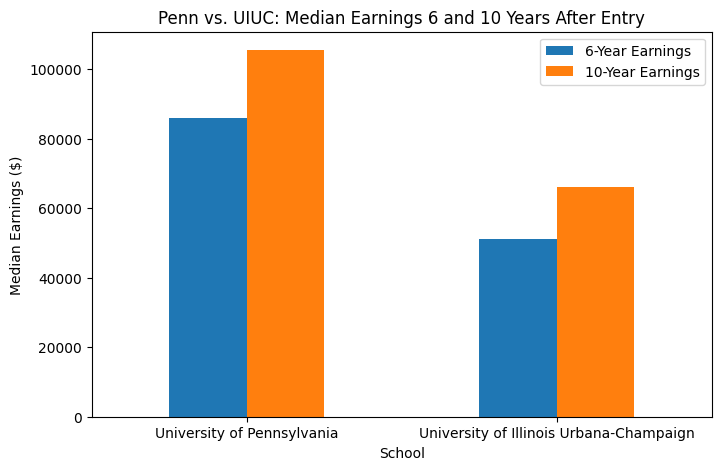

In [78]:
earnings_compare.plot(kind="bar", figsize=(8,5))

plt.title("Penn vs. UIUC: Median Earnings 6 and 10 Years After Entry")
plt.xlabel("School")
plt.ylabel("Median Earnings ($)")
plt.xticks(rotation=0)
plt.legend(["6-Year Earnings", "10-Year Earnings"])

plt.show()

**The Penn name still holds considerable economic value, especially given Penn's pathways into finance, consulting, and investment banking. UPenn also offers considerable alumni networks which could all be reasons for such a huge salary difference. However, there is definitely more to uncover about the story outside of just salary.**

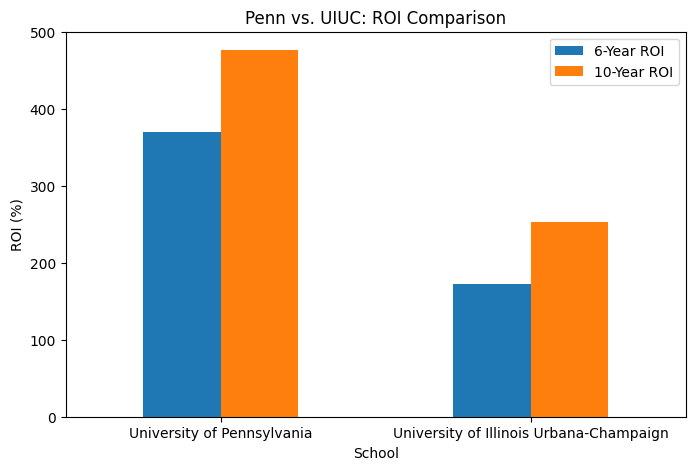

In [80]:
compare.set_index("School")[["roi_6yr", "roi_10yr"]].plot(kind="bar", figsize=(8,5))

plt.title("Penn vs. UIUC: ROI Comparison")
plt.ylabel("ROI (%)")
plt.xlabel("School")
plt.xticks(rotation=0)
plt.legend(["6-Year ROI", "10-Year ROI"])

plt.show()

**Comparing each school’s average annual net cost with students’ median earnings after graduation, Penn had nearly double UIUC’s return on investment both at six years and 10 years. This went against the preconceived notion that public universities or state schools offer a better financial offer long-term. Penn’s higher post-graduation earnings offset the school’s overall higher costs much more dramatically. This led us to consider another factor, which was student debt.**

# Second Takeaway: There isn't much of a suprising difference in debt post-grad

In [31]:
subset = cleaned_df[["School", "Median Debt at Graduation",
       "Avg Annual Cost (Net Price)"]]

**Below is a compiled dataset from the government of median debt at graduation for all students in the Ivy League (UPenn) and Big Ten conference (UIUC)**

In [32]:
subset.head(19)

,School,Median Debt at Graduation,Avg Annual Cost (Net Price)
0,Harvard University,$12800,$17000
1,Yale University,$11800,$17600
2,Princeton University,$8700,$15500
3,Columbia University,$20500,$18800
4,University of Pennsylvania,$18300,$18300
5,Dartmouth College,$14500,$22600
6,Brown University,$16700,$26000
7,Cornell University,$19500,$28500
8,University of Michigan,$18200,$16800
9,University of Illinois Urbana-Champaign,$19300,$18700


In [33]:
cols = ["earnings_6yr", "earnings_10yr", 
        "Median Debt at Graduation", 
        "Avg Annual Cost (Net Price)"]

for col in cols:
    cleaned_df[col] = (
        cleaned_df[col]
        .replace('[$,]', '', regex=True)  
        .astype(float)
    )

In [81]:
another = compare.set_index("School")[["Median Debt at Graduation"]]

In [82]:
another

,Median Debt at Graduation
School,
University of Pennsylvania,18300.0
University of Illinois Urbana-Champaign,19300.0


**This reveals that Penn and UIUC students have similar debt levels at graduation. UIUC students have a median debt of $19,300 while Upenn students have a median debt of $18,300. UIUC has a slightly higher median debt, but are around similar levels.**

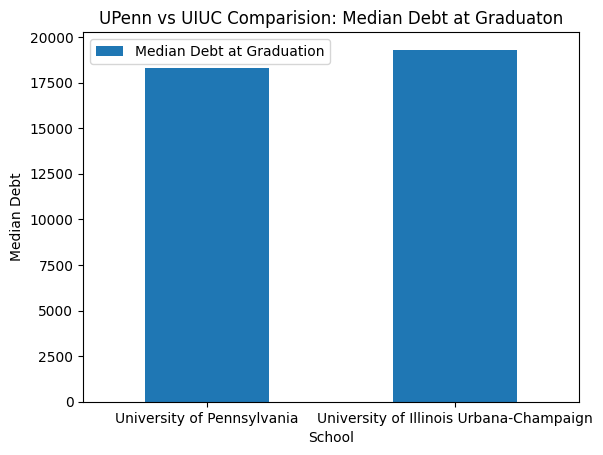

In [83]:
compare.set_index("School")[["Median Debt at Graduation"]].plot(kind="bar")

plt.title("UPenn vs UIUC Comparision: Median Debt at Graduaton")
plt.ylabel("Median Debt")
plt.xticks(rotation=0)
plt.show()

**Although Ivy League schools are expected to leave students with considerable debt in comparison to a more practical option like state schools, this data conflicts with this expectation, indicating that UIUC students leave with slightly higher median debt.**

## How does the student debt compare to what they earn post-grad?

In [70]:
cleaned_df["roi_6yr"] = (
    (cleaned_df["earnings_6yr"] - cleaned_df["Avg Annual Cost (Net Price)"])
    / cleaned_df["Avg Annual Cost (Net Price)"]
) * 100

cleaned_df["roi_10yr"] = (
    (cleaned_df["earnings_10yr"] - cleaned_df["Avg Annual Cost (Net Price)"])
    / cleaned_df["Avg Annual Cost (Net Price)"]
) * 100

cleaned_df["debt_to_income"] = (
    cleaned_df["Median Debt at Graduation"] / cleaned_df["earnings_6yr"]
) * 100

cleaned_df["growth"] = cleaned_df["earnings_10yr"] - cleaned_df["earnings_6yr"]

In [85]:
third = compare.set_index("School")[["debt_to_income"]]

In [86]:
third

,debt_to_income
School,
University of Pennsylvania,21.303842
University of Illinois Urbana-Champaign,37.843137


**If you look at the debt_to_income column in the chart, Penn’s debt-to-income ratio is about 17.3%, while UIUC’s is about 29.2%.**

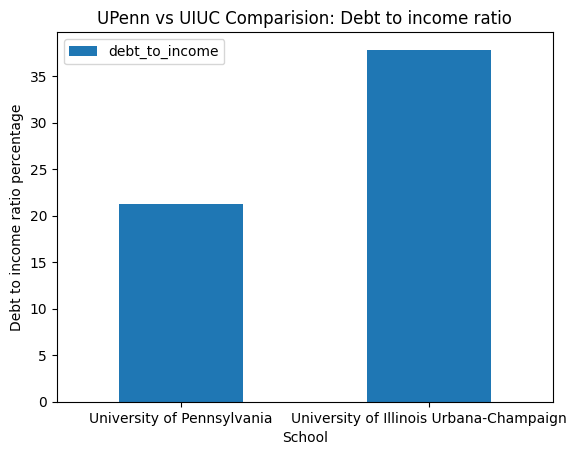

In [88]:
compare.set_index("School")[["debt_to_income"]].plot(kind="bar")

plt.title("UPenn vs UIUC Comparision: Debt to income ratio")
plt.ylabel("Debt to income ratio percentage")
plt.xticks(rotation=0)
plt.show()

**Even with similar debt levels, as Penn students earn more post-grad, Penn’s debt-to-income ratio (debt compared to relative income post graduation) is much lower. Penn’s debt-to-income ratio is at 17.3% compared to UIUC’s 29.2%. The data indicates that UIUC graduates carry a bigger financial burden post graduation even with similar debt levels. It seems that Penn students are left in a more favorable financial position at graduation.**

# BUT

**Although Penn students produce higher-earning graduates, the institution also enrolls an already wealthier student demographic.**

In [47]:
mobility_df = pd.read_csv('/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project/data/raw/Overall_data/upenn_mobility_clean.csv')

# Third Takeaway: Penn students come from more wealthier family backgrounds overall 

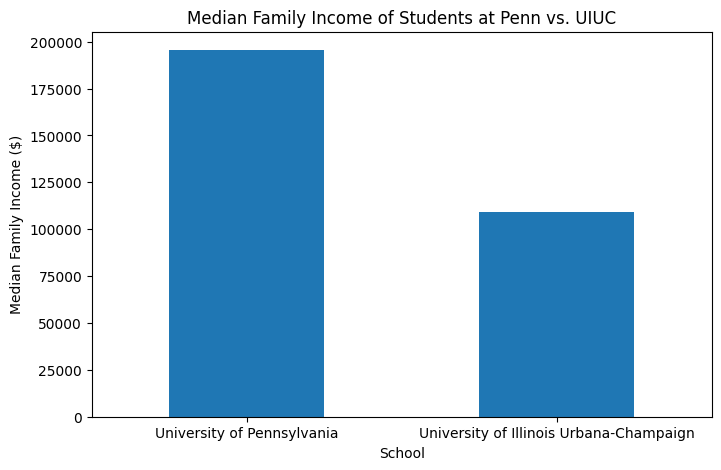

In [48]:
mobility_df.plot(
    x="school",
    y="median_family_income",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Median Family Income of Students at Penn vs. UIUC")
plt.xlabel("School")
plt.ylabel("Median Family Income ($)")
plt.xticks(rotation=0)
plt.show()

**Based on the New York Times mobility index report card data gathered from tax records, Penn students come from wealthier households in comparison to UIUC students. The median family income of Penn students is $195,500 and for UIUC, $109,000. This is an important metric to consider, highlighting Penn students’ pre-existing advantages of coming from a higher income background.**

**The median family income of Penn students is $195,500 compared to UIUC students at $109,000**

## Income Demographics Visual Comparision

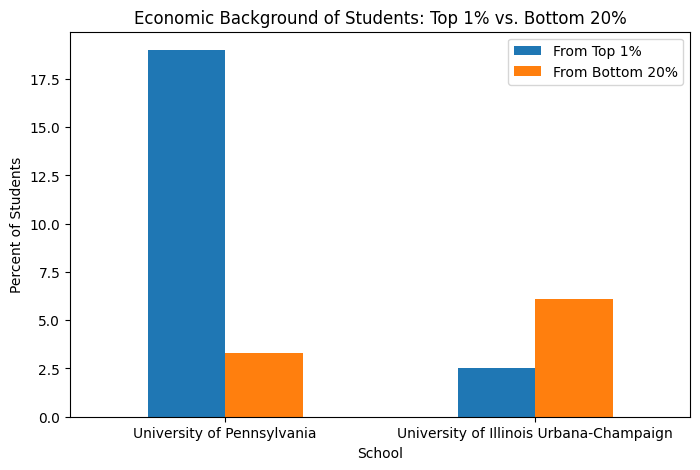

In [49]:
wealth_access = mobility_df.set_index("school")[[
    "pct_from_top_1",
    "pct_from_bottom_20"
]]

wealth_access.plot(kind="bar", figsize=(8,5))

plt.title("Economic Background of Students: Top 1% vs. Bottom 20%")
plt.xlabel("School")
plt.ylabel("Percent of Students")
plt.xticks(rotation=0)
plt.legend(["From Top 1%", "From Bottom 20%"])
plt.show()

**Penn also enrolls a higher group of students from the top 1%, white UIUC enrolls students largely from the bottom 20%. Penn salaries’ can also be a reflection of pre-existing socioeconomic advantages that include things like networks, family wealth, and accessibility to elite career fields.**

# Fourth takeaway: UIUC is stronger in broader economic mobility

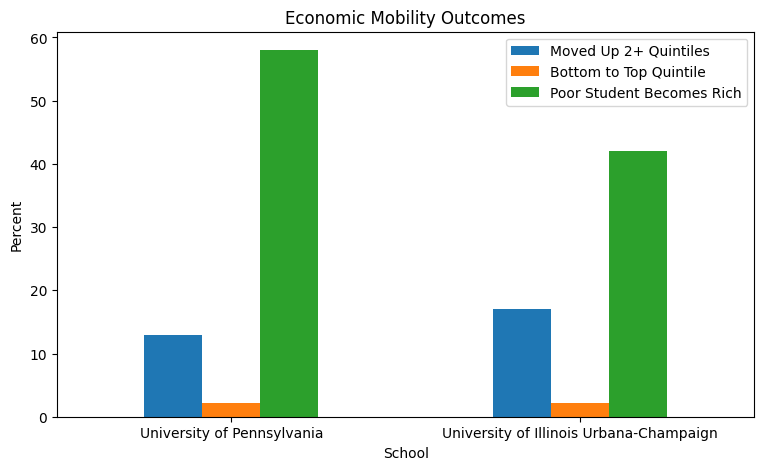

In [11]:
mobility_metrics = mobility_df.set_index("school")[[
    "pct_moved_up_2plus_quintiles",
    "pct_bottom_to_top_quintile",
    "pct_poor_student_becomes_rich"
]]

mobility_metrics.plot(kind="bar", figsize=(9,5))

plt.title("Economic Mobility Outcomes")
plt.xlabel("School")
plt.ylabel("Percent")
plt.xticks(rotation=0)
plt.legend([
    "Moved Up 2+ Quintiles",
    "Bottom to Top Quintile",
    "Poor Student Becomes Rich"
])
plt.show()

**UIUC seems to be stronger than Penn in this financial component, which is broader economic mobility. The data indicates that UIUC has a higher proportion of students moving up two or more income quintiles, suggesting that the school may serve as a stronger force for economic mobility across income groups instead of a concentrated group of high-income students. However, it is important to note that Penn does have a higher percentage of economic mobility in terms of moving the specific demographic of low-income students to the highest income threshold, but less of the overall student body.**

# Fifth Takeaway: Geography may inflate Penn grad's salary

## Median Individual Income at Age 34

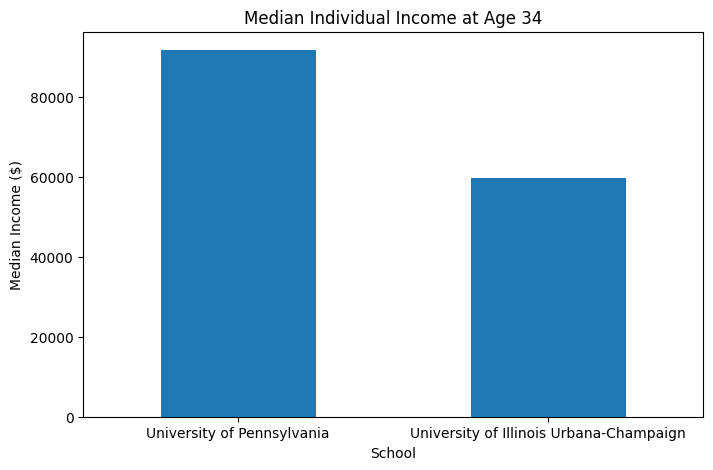

In [51]:
mobility_df.plot(
    x="school",
    y="median_individual_income_age34",
    kind="bar",
    legend=False,
    figsize=(8,5)
)

plt.title("Median Individual Income at Age 34")
plt.xlabel("School")
plt.ylabel("Median Income ($)")
plt.xticks(rotation=0)
plt.show()

**By age 34, Penn graduates earn substantially more than UIUC graduates, which makes sense given our previous analysis of the data.**

**An interesting observation we came across was that the location of Penn graduates could either inflate or deflate their salaries’ value. Median income levels of Penn graduates are significantly higher than UIUC as analyzed above, but it is important to also consider the context of where Penn and UIUC graduates live post-graduation.**

In [62]:
cities_df = pd.read_csv('/Commjhub/jupyterhub/home/emch06/comm3180_S26/comm3180_G3_Data_Project/data/raw/Overall_data/upenn_alumni_cities.csv')

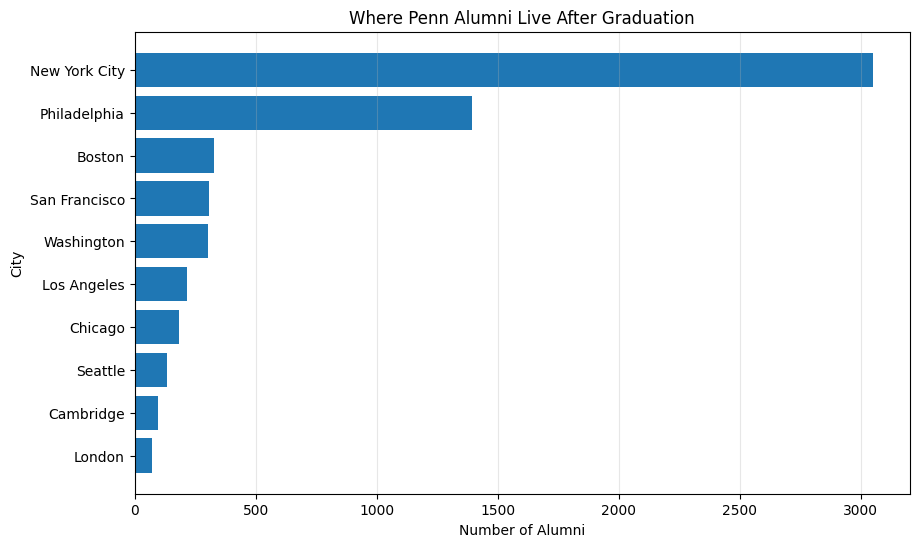

In [63]:
penn_df = cities_df.query('school == "University of Pennsylvania"')

penn_df = penn_df.sort_values("alumni_count")

plt.figure(figsize=(10,6))

plt.barh(
    penn_df["city"],
    penn_df["alumni_count"]
)

plt.xlabel("Number of Alumni")
plt.ylabel("City")

plt.title("Where Penn Alumni Live After Graduation")

plt.grid(axis="x", alpha=0.3)

plt.show()

**More Penn grads are concentrated in major cities like New York City, Philadelphia, Boston, San Francisco, Washington, and Los Angeles, with more variation.**

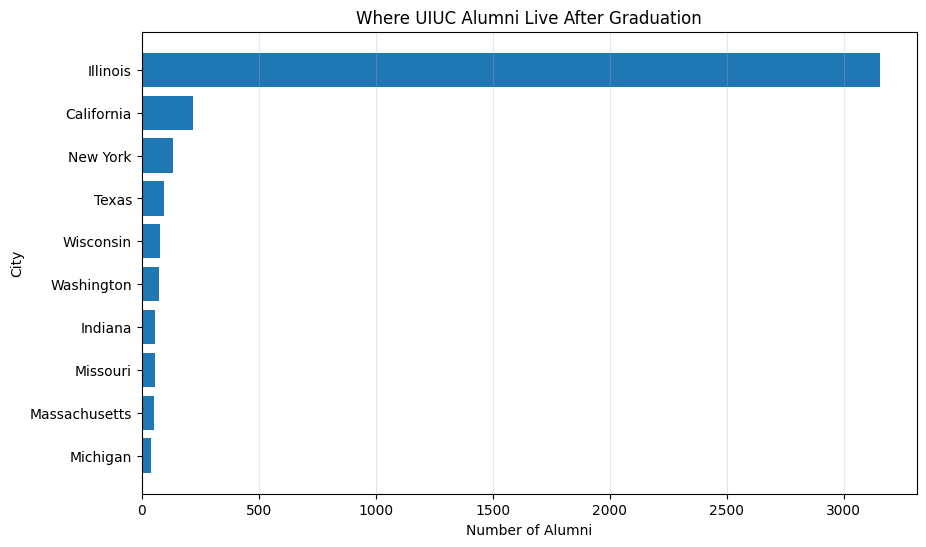

In [64]:
uiuc_df = cities_df.query('school == "University of Illinois Urbana-Champaign"')

uiuc_df = uiuc_df.sort_values("alumni_count")

plt.figure(figsize=(10,6))

plt.barh(
    uiuc_df["city"],
    uiuc_df["alumni_count"]
)

plt.xlabel("Number of Alumni")
plt.ylabel("City")

plt.title("Where UIUC Alumni Live After Graduation")

plt.grid(axis="x", alpha=0.3)

plt.show()

**Most of the UIUC grads are concentrated significantly in Illinois with less variation in other states.**

**The data revealed that Penn grads are more concentrated in major cities that have higher costs of living than UIUC grads who live mostly in Chicago and the Midwestern area. The higher salaries of Penn students could be potentially deflated by the city which they live in, as the city involves more expenses. Penn graduates do have a salary advantage, but it is not a whole advantage considering where they live.**

# FINAL TAKEAWAYS

1) On average, Penn grads earn substantially more than UIUC grads

2) There isn’t much of a suprising difference in debt post-grad

3) UIUC is stronger in broader economic mobility

4) Geography may inflate Penn grad's salary

**Conclusion:** The discussion is much more nuanced than just determining who ultimately has a better financial outcome. Penn’s status appears to translate into stronger overall earnings and a better debt-to-income position after graduation. But we need to also consider the fact that Penn students come from much wealthier backgrounds in the top 1%, giving the students more access and an already to begin with socioeconomic advantage.

UIUC may not match Penn’s salary numbers numerically, but the school has a different role. As a large public university, the school appears to offer broader access and stronger upward income mobility for a wider range of students, especially those low income. But keep in mind that Penn has a higher percentage in moving low-income students to the highest income threshhold.

**Although Penn seemed to provide stronger financial outcomes overall, UIUC was a stronger force for broader income mobility across socioeconomic groups.** If success means a higher salary, Penn would lead UIUC with stronger ROI metrics and a lower debt-to-income ratio. However, a majority of Penn graduates are concentrated in major cities where the cost of living is high, which slightly negates this impact. If success means a broader economic mobility, UIUC would lead Penn as the school enrolls students from a much less wealthier background and appears to move a larger group of students upward across income quintiles. 